# Humans vs. LLMs: Why AI-Driven Title Optimization Can Outperform Human Intuition

This research paper explores the comparative performance of human-generated video titles versus those optimized by Large Language Models (LLMs) through an iterative feedback loop.

In [1]:
# Setup and Dependencies
!pip install -q sentence-transformers

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/numeric_inference_outputs/'
RESULTS_PATH = os.path.join(BASE_PATH, 'title_optimization_results.json')
EVAL_DATA_PATH = os.path.join(BASE_PATH, 'top_significant_channels_eval.json')
LLM_RESULTS_PATH = os.path.join(BASE_PATH, 'llm_analysis_results.json')
TRAIN_DATA_PATH = os.path.join(BASE_PATH, 'train_structured_latest.json')
EMBEDDING_CACHE_PATH = os.path.join(BASE_PATH, 'video_title_embeddings_latest.json')
EMBEDDING_MODEL_NAME = 'all-MiniLM-L6-v2'

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

with open(RESULTS_PATH, 'r') as f:
    results = json.load(f)

with open(EVAL_DATA_PATH, 'r') as f:
    eval_dataset = json.load(f)

with open(LLM_RESULTS_PATH, 'r') as f:
    llm_analysis = json.load(f)

with open(TRAIN_DATA_PATH, 'r') as f:
    train_data = json.load(f)

with open(EMBEDDING_CACHE_PATH, 'r') as f:
    embedding_cache = json.load(f)

# PCA Reconstruction
all_train_embeddings = []
for channel in train_data:
    for video in channel['videos']:
        if video['title'] in embedding_cache:
            all_train_embeddings.append(embedding_cache[video['title']])

X_train = np.array(all_train_embeddings)
pca = PCA(n_components=15, random_state=42)
pca.fit(X_train)

df = pd.DataFrame(results)
print(f"Loaded {len(df)} optimization results.")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded 20 optimization results.


## Hypothesis: LLMs Can Discover High-Performance Titles Beyond Human Intuition

### Methodology
We utilize an iterative optimization loop where an LLM (Gemini 3.1 Flash lite) generates titles, which are then scored by a per-channel OLS model. This feedback is used to refine suggestions over 5 rounds.

### Hypotheses
- **Null Hypothesis (H0)**: Human-generated titles (original) represent the performance ceiling for a given video topic.
- **Alternative Hypothesis (H1)**: Iterative LLM optimization can discover semantic representations that predict higher view counts than human-authored titles by navigating the latent space more effectively.

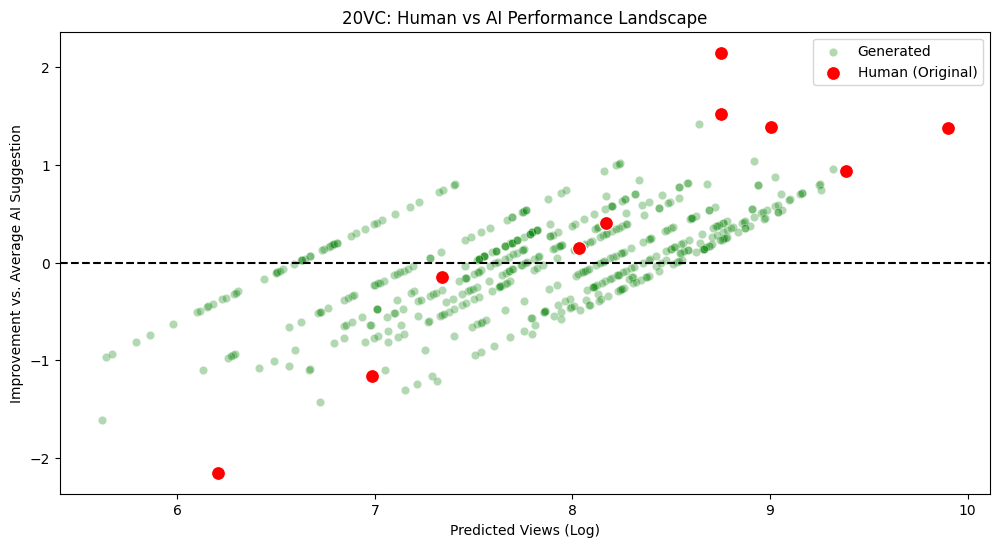

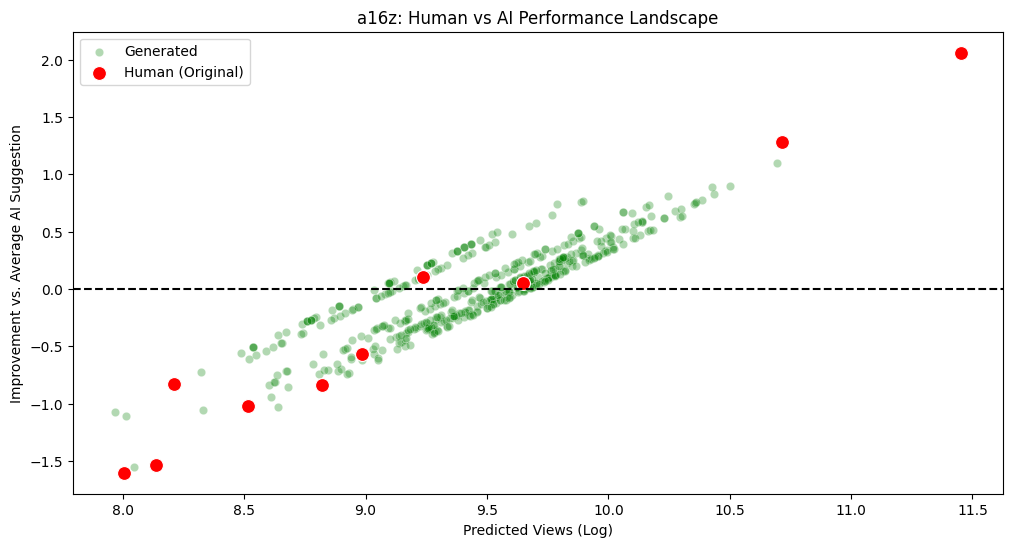

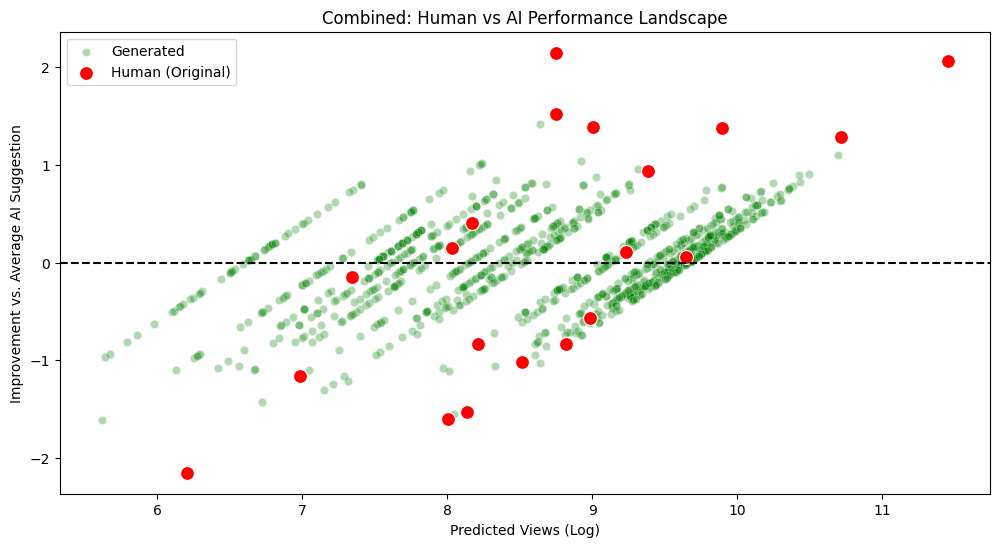

In [43]:
def plot_improvement_scatter(df, channel_filter=None, title="Title Performance Comparison"):
    plot_df = df.copy() if channel_filter is None else df[df['channel'] == channel_filter]

    human_data = []
    ai_data = []

    for _, row in plot_df.iterrows():
        # Calculate average score of all AI suggestions for this video across all iterations
        all_ai_scores = []
        for it in row['history']:
            for t in it['titles']:
                all_ai_scores.append(t['score'])

        avg_ai_score = np.mean(all_ai_scores)

        # Human performance: original_score vs (original_score - avg_ai_score)
        human_data.append({
            'pred_views': row['original_score'],
            'improvement': row['original_score'] - avg_ai_score,
            'type': 'Human'
        })

        # AI performance: each suggestion's score vs (score - avg_ai_score)
        for it in row['history']:
            for t in it['titles']:
                ai_data.append({
                    'pred_views': t['score'],
                    'improvement': t['score'] - avg_ai_score,
                    'type': 'AI'
                })

    h_df = pd.DataFrame(human_data)
    a_df = pd.DataFrame(ai_data)

    plt.figure(figsize=(12, 6))
    # Note: Using small alpha for AI data to see Human points clearly
    sns.scatterplot(data=a_df, x='pred_views', y='improvement', color='green', alpha=0.3, label='Generated')
    sns.scatterplot(data=h_df, x='pred_views', y='improvement', color='red', s=100, label='Human (Original)')

    plt.axhline(0, color='black', linestyle='--')
    plt.title(title)
    plt.xlabel("Predicted Views (Log)")
    plt.ylabel("Improvement vs. Average AI Suggestion")
    plt.legend()
    plt.show()

# 1. 20VC Scatter
plot_improvement_scatter(df, "20VC with Harry Stebbings", "20VC: Human vs AI Performance Landscape")

# 2. a16z Scatter
plot_improvement_scatter(df, "a16z", "a16z: Human vs AI Performance Landscape")

# 3. Combined Scatter
plot_improvement_scatter(df, None, "Combined: Human vs AI Performance Landscape")

## Success Determinants: Dimension Weights and Significance

What determines success for a video? We analyze the contribution (weight coefficient) of each dimension, ordered by significance.

In [27]:
def show_dimension_importance(channel_name, eval_dataset):
    channel_data = next(c for c in eval_dataset if c['channel_name'].lower() == channel_name.lower())
    coeffs = channel_data['model']['coefficients']
    p_values = channel_data['model']['p_values']

    # Skip the first p_value
    p_values = p_values[1:]

    # Debugging: Print lengths of coeffs and p_values
    print(f"Length of coefficients: {len(coeffs)}")
    print(f"Length of p-values: {len(p_values)}")

    # Print values of coeffs and p_values
    print("Coefficients:", coeffs)
    print("p-values:", p_values)

    print(channel_data['model'].keys())

    importance_df = pd.DataFrame({
        'Dimension': [f'Dim {i}' for i in range(len(coeffs))],
        'Weight': coeffs,
        'Significance (p-value)': p_values
    })

    importance_df['AbsWeight'] = importance_df['Weight'].abs()
    importance_df = importance_df.sort_values('Significance (p-value)', ascending=True).drop(columns=['AbsWeight'])

    print(f"### Dimension Contribution for {channel_name}")
    display(importance_df.reset_index(drop=True))

In [28]:
show_dimension_importance("20VC with Harry Stebbings", eval_dataset)

Length of coefficients: 15
Length of p-values: 15
Coefficients: [1.8833464405590432, 1.1301301613233157, -2.319853078494216, 4.519999590032794, 1.8114643412732419, -2.3205483182275315, -1.2966718259822183, 1.7534750506069978, -0.7638972765373375, -0.27711776110317055, 0.15532324388839513, 1.665535559061076, 1.4811944807591928, -1.3849869676982887, -1.9651566656165533]
p-values: [5.7613311867306535e-05, 0.0068475707026208225, 4.5863502938372154e-09, 3.52271985165948e-17, 0.0001061459410771146, 3.769249517742632e-05, 0.022724258222644362, 0.0008658213048551761, 0.14842173072339174, 0.6032460089922722, 0.7936749402611295, 0.007480302776970657, 0.009277128180448369, 0.013571736539217118, 0.0009975496622535095]
dict_keys(['intercept', 'coefficients', 'p_values'])
### Dimension Contribution for 20VC with Harry Stebbings


,Dimension,Weight,Significance (p-value)
0,Dim 3,4.520000,3.522720e-17
1,Dim 2,-2.319853,4.586350e-09
2,Dim 5,-2.320548,3.769250e-05
3,Dim 0,1.883346,5.761331e-05
4,Dim 4,1.811464,1.061459e-04
5,Dim 7,1.753475,8.658213e-04
6,Dim 14,-1.965157,9.975497e-04
7,Dim 1,1.130130,6.847571e-03
8,Dim 11,1.665536,7.480303e-03
9,Dim 12,1.481194,9.277128e-03


In [29]:
show_dimension_importance("a16z", eval_dataset)

Length of coefficients: 15
Length of p-values: 15
Coefficients: [0.2547188621199246, 2.149223559087092, -1.3716308794589573, 2.6622885034439356, 0.11931453488346544, -0.6564698228127149, -0.5736960630982566, -0.5784974380092388, 0.3432165523933113, 1.365428865575805, -0.042673746050204464, 0.19772725720175882, -1.4769965008845503, 1.177837709915119, 0.5250542739418957]
p-values: [0.6524760460436748, 0.00017927622037635185, 0.007938115366145781, 0.00014763983846306723, 0.8632219769327928, 0.31645094534720486, 0.36050231364011764, 0.4236018326726366, 0.5998450679795285, 0.08639386715317521, 0.9537501792463653, 0.7671934961966538, 0.042983321999541364, 0.1900922024209898, 0.524911566520868]
dict_keys(['intercept', 'coefficients', 'p_values'])
### Dimension Contribution for a16z


,Dimension,Weight,Significance (p-value)
0,Dim 3,2.662289,0.000148
1,Dim 1,2.149224,0.000179
2,Dim 2,-1.371631,0.007938
3,Dim 12,-1.476997,0.042983
4,Dim 9,1.365429,0.086394
5,Dim 13,1.177838,0.190092
6,Dim 5,-0.656470,0.316451
7,Dim 6,-0.573696,0.360502
8,Dim 7,-0.578497,0.423602
9,Dim 14,0.525054,0.524912


## Human vs. AI Performance: A Comparative Analysis

These tables compare human-generated titles against AI optimized ones, including the relative difference to the best and average AI suggestions.

In [56]:
def create_human_ai_comparison(df, channel_name, eval_dataset, pca, embedding_model):
    channel_df = df[df['channel'] == channel_name]
    channel_eval = next(c for c in eval_dataset if c['channel_name'].lower() == channel_name.lower())
    coeffs = np.abs(channel_eval['model']['coefficients'])
    top_5_dims = np.argsort(coeffs)[-5:][::-1]

    rows = []
    for _, row in channel_df.iterrows():
        video_eval = next(v for v in channel_eval['test_videos'] if v['video_id'] == row['video_id'])
        real_views = video_eval['actual_views']

        all_ai_scores = []
        for it in row['history']:
            for t in it['titles']:
                all_ai_scores.append(t['score'])

        best_ai_score = max(all_ai_scores)
        avg_ai_score = np.mean(all_ai_scores)

        # Truncate titles for visibility if needed
        # Comment: We use a limit of 100 characters to ensure full titles are mostly visible while preventing overflow
        def truncate(t): return (t[:499] + '...') if len(t) > 500 else t

        emb = embedding_model.encode([row['original_title']])
        proj = pca.transform(emb)[0]

        res = {
            'Human Title': truncate(row['original_title']),
            'Real Views': int(real_views),
            'Pred Score': f"{row['original_score']:.4f}",
            'vs. Best AI': f"{row['original_score'] - best_ai_score:+.4f}",
            'vs. Avg AI': f"{row['original_score'] - avg_ai_score:+.4f}"
        }
        for d in top_5_dims:
            res[f'Dim {d}'] = f"{proj[d]:.4f}"

        rows.append(res)

        # Order by predicted views (top to bottom). Use numbers.
        rows.sort(key=lambda x: float(x['Pred Score']), reverse=True)

    print(f"### Human vs AI Comparison: {channel_name}")
    display(pd.DataFrame(rows))


In [51]:
create_human_ai_comparison(df, "20VC with Harry Stebbings", eval_dataset, pca, embedding_model)

### Human vs AI Comparison: 20VC with Harry Stebbings


,Human Title,Real Views,Pred Score,vs. Best AI,vs. Avg AI,Dim 3,Dim 5,Dim 2,Dim 14,Dim 0
0,"Sridhar Ramaswamy, CEO @Snowflake: Deepseek is...",19902,9.8986,+0.6384,+1.3765,0.0934,-0.0303,0.0483,-0.1943,0.1523
1,Arthur Mensch: Open vs Closed - Who Wins and M...,11919,9.3860,+0.1347,+0.9347,0.1950,-0.0151,0.1923,0.1361,0.1170
2,"Plural Partner, Taavet Hinrikus: Why Founders ...",8151,9.0060,+0.6880,+1.3878,0.1947,0.0188,-0.1284,0.0762,-0.2453
3,David Meyer: Why You Should Hire People Who Ar...,6319,8.7515,+0.1101,+1.5222,0.1020,0.0356,-0.1989,0.0351,0.0882
4,"Julian Teixeira, CRO @ 1Password: How to Hire ...",6314,8.7507,+1.3432,+2.1458,-0.0547,0.0513,-0.2244,-0.0606,0.0615
5,Joey Zwillinger: From $4.1BN to $142M Market C...,3529,8.1691,-0.4152,+0.4031,0.1858,-0.0546,-0.0611,0.0255,-0.2468
6,Snap's VP of Product Jack Brody: The Future of...,3076,8.0317,-0.8891,+0.1533,0.1194,-0.1198,0.0476,-0.0456,0.1324
7,Kevin Egan: Biggest Lesson on Managing Sales T...,1541,7.3408,-0.9957,-0.1495,0.1272,0.0825,-0.2092,0.1105,0.0121
8,How I Became the Head of Instagram -- Adam Mos...,1079,6.9847,-2.0421,-1.1644,0.0446,-0.1884,-0.0357,-0.1300,0.2021
9,Stable Diffusion Creator Analyzes the OpenAI-M...,496,6.2086,-3.1106,-2.1496,0.0547,-0.1026,-0.1371,-0.0346,0.1167


In [57]:
create_human_ai_comparison(df, "a16z", eval_dataset, pca, embedding_model)

### Human vs AI Comparison: a16z


,Human Title,Real Views,Pred Score,vs. Best AI,vs. Avg AI,Dim 3,Dim 1,Dim 12,Dim 2,Dim 9
0,Truth Terminal - The AI Bot That Became a Cryp...,94035,11.4514,+1.3916,+2.0616,-0.0601,0.1896,-0.0057,-0.1159,0.1191
1,Marc Andreessen & Amjad Masad on “Good Enough”...,45118,10.7171,+0.4692,+1.2801,0.1223,0.1096,-0.0610,-0.0939,-0.1591
2,GPT-5 and Agents Breakdown – w/ OpenAI Researc...,15514,9.6496,-1.0449,+0.0517,0.0697,0.0401,0.1284,0.0342,-0.1620
3,Reasoning Models Are Remaking Professional Ser...,10250,9.2351,-0.6589,+0.1085,-0.1203,-0.0974,0.1215,-0.0602,-0.2216
4,AI & The Future of Modern Warfare,7973,8.9839,-1.1554,-0.5660,-0.0392,0.3491,-0.0062,0.0477,-0.1074
5,The 2045 Superintelligence Timeline: Epoch AI’...,6765,8.8197,-1.3523,-0.8353,-0.0188,0.3462,-0.0274,-0.0375,0.0431
6,How to Enable a Manufacturing Renaissance,4997,8.5168,-1.9119,-1.0193,-0.1483,-0.0017,0.0441,-0.1522,0.0014
7,"Mark Cuban on the NBA, Cost Plus Drugs, and Ho...",3686,8.2126,-1.5756,-0.8310,0.1025,-0.2315,-0.0721,0.1486,0.0350
8,JD Vance on the Future of America,3417,8.1368,-2.1670,-1.5321,0.2374,-0.0579,0.1375,0.2040,-0.0398
9,Udio: From Text to Tune,2990,8.0034,-2.4300,-1.6033,-0.1132,-0.0055,0.0272,0.0515,-0.1830


## Iterative Refinement: The Prompting Strategy

The optimization process utilizes a 5-round feedback loop. Below are examples of the prompts used.

### Initial Generation Prompt
This prompt is used in the first iteration to set the baseline and explore the semantic space based on global success drivers.

In [58]:
initial_prompt_example = """You are an expert YouTube title strategist for the channel 'A16z'.
Channel success drivers:
[Detailed qualitative analysis of what drives views...]

Semantic performance analysis:
[Analysis of significant PCA dimensions...]

Original Title: Udio: From Text to Tune
Current best predicted performance (log-views): 8.0034

Task: Generate 10 new, improved titles for this video that will maximize views based on the channel's success drivers and semantic analysis. Return ONLY the 10 titles, one per line."""
print(initial_prompt_example)

You are an expert YouTube title strategist for the channel 'A16z'.
Channel success drivers:
[Detailed qualitative analysis of what drives views...]

Semantic performance analysis:
[Analysis of significant PCA dimensions...]

Original Title: Udio: From Text to Tune
Current best predicted performance (log-views): 8.0034

Task: Generate 10 new, improved titles for this video that will maximize views based on the channel's success drivers and semantic analysis. Return ONLY the 10 titles, one per line.


### Feedback-Based Refinement Prompt
In subsequent rounds, the LLM receives feedback on its previous suggestions, enabling a "hill-climbing" optimization.

In [59]:
refinement_prompt_example = """[... previous context ...]

Previous suggestions feedback:
Top performing suggestions:
- The Future of Sound: Inside the AI Startup Disrupting the $25B Music Industry (Score: 10.4334)
- ...

Lower performing suggestions (Avoid these patterns):
- Why Udio is Changing Everything (Score: 8.5)
- ...

Task: Generate 10 new, improved titles for this video..."""
print(refinement_prompt_example)

[... previous context ...]

Previous suggestions feedback:
Top performing suggestions:
- The Future of Sound: Inside the AI Startup Disrupting the $25B Music Industry (Score: 10.4334)
- ...

Lower performing suggestions (Avoid these patterns):
- Why Udio is Changing Everything (Score: 8.5)
- ...

Task: Generate 10 new, improved titles for this video...


## Individual Dimension Analysis: Driving Positive Direction

We analyze how titles correlate with the positive direction of each significant dimension. This section explicitly indicates the intended direction for performance optimization.

In [35]:
def analyze_individual_dimensions(df, channel_name, eval_dataset, pca, embedding_model):
    channel_df = df[df['channel'] == channel_name]
    channel_eval = next(c for c in eval_dataset if c['channel_name'].lower() == channel_name.lower())
    coeffs = channel_eval['model']['coefficients']
    top_5_indices = np.argsort(np.abs(coeffs))[-5:][::-1]

    print(f"### Individual Dimension Breakdown for {channel_name}")

    for dim_idx in top_5_indices:
        weight = coeffs[dim_idx]
        direction = "INCREASE" if weight > 0 else "DECREASE"

        # Extract values for this dimension for all optimized titles
        all_optimized_titles = []
        for _, row in channel_df.iterrows():
            for it in row['history']:
                for t in it['titles']:
                    all_optimized_titles.append(t['text'])

        all_optimized_titles = list(set(all_optimized_titles))
        embs = embedding_model.encode(all_optimized_titles)
        projs = pca.transform(embs)[:, dim_idx]

        avg_val = np.mean(projs)

        plt.figure(figsize=(10, 4))
        sns.histplot(projs, kde=True, color='blue' if weight > 0 else 'orange')
        plt.axvline(avg_val, color='red', linestyle='--', label=f'Avg: {avg_val:.4f}')
        plt.title(f"Dimension {dim_idx} Distribution (Weight: {weight:.4f}) - Should {direction}")
        plt.legend()
        plt.show()

        # Top 5 titles for this dimension (considering direction)
        sorted_indices = np.argsort(projs)
        if weight > 0:
            top_indices = sorted_indices[-5:][::-1]
        else:
            top_indices = sorted_indices[:5]

        print(f"Top titles for Dim {dim_idx} (direction: {direction}):")
        for idx in top_indices:
            print(f"- {all_optimized_titles[idx]} (Value: {projs[idx]:.4f})")
        print("\n")


### Individual Dimension Breakdown for 20VC with Harry Stebbings


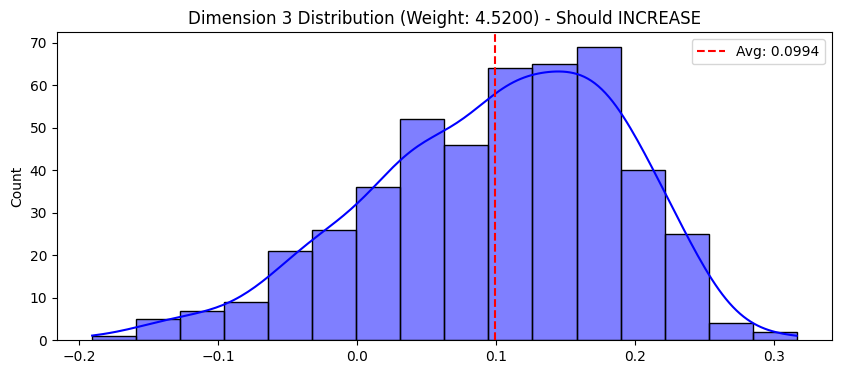

Top titles for Dim 3 (direction: INCREASE):
- The AI War: Mistral CEO Arthur Mensch on Beating the Incumbents (Value: 0.3161)
- The AI Power Shift: Mistral CEO Arthur Mensch on Scaling Against the Incumbents (Value: 0.2877)
- Joey Zwillinger on the Allbirds Crash: Why the Markets Turned Against Us (Value: 0.2698)
- Mistral CEO Arthur Mensch: The End of The OpenAI Monopoly (Value: 0.2604)
- Joey Zwillinger: Why $4BN Companies Die in Public Markets | E1078 (Value: 0.2538)




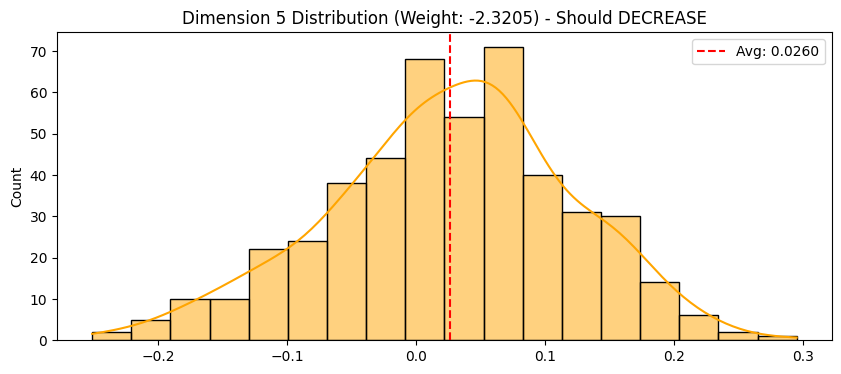

Top titles for Dim 5 (direction: DECREASE):
- From Unicorn to $142M: Joey Zwillinger on the Anatomy of the Allbirds Collapse | E1078 (Value: -0.2510)
- Joey Zwillinger: The Allbirds Story - From $4BN Unicorn to $142M Public Reality | E1078 (Value: -0.2404)
- The $3.8BN Wipeout: Joey Zwillinger on the Hard Lessons from the Allbirds Crash | E1078 (Value: -0.2199)
- Beyond the App: Snap VP Jack Brody on Evan Spiegel’s Vision for AR Monetization and Hardware Dominance | E1006 (Value: -0.2134)
- Beyond the Filter: Snap VP Jack Brody on the $100BN Hardware Challenge and AR Monetization (Value: -0.2011)




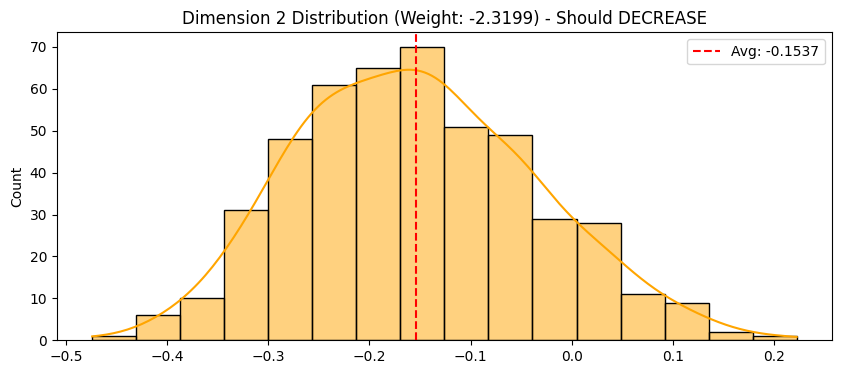

Top titles for Dim 2 (direction: DECREASE):
- Adam Mosseri: The Truth About Why Most AI Startups Are Not Real Businesses (Value: -0.4740)
- How to Build a $1BN Product Organization: The Counter-Intuitive Hiring Playbook (Value: -0.4129)
- How to Build a $1BN Revenue Machine: Kevin Egan’s Slack & Atlassian Playbook | E1034 (Value: -0.4127)
- Adam Mosseri: Why You Should Not Build an AI Startup on Top of Big Tech APIs (Value: -0.4012)
- How to Build a $10BN Product Machine: The Hiring Rules You Haven’t Heard (Value: -0.3986)




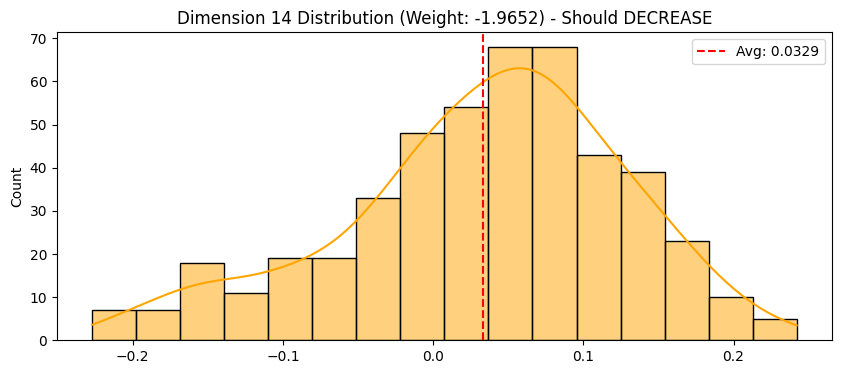

Top titles for Dim 14 (direction: DECREASE):
- Instagram’s Head of Product: How to Build a Growth Machine and Dominate Global Markets (Value: -0.2271)
- OpenAI’s Lead Over Anthropic: Snowflake CEO Sridhar Ramaswamy’s Market Prediction (Value: -0.2137)
- Snowflake CEO Sridhar Ramaswamy: The Definitive Verdict on OpenAI, Anthropic, and DeepSeek (Value: -0.2102)
- Adam Mosseri: How Meta Uses Proprietary Data to Defend Against OpenAI and Google (Value: -0.2092)
- Snowflake CEO Sridhar Ramaswamy: OpenAI vs. Anthropic — Who Controls the Future of AI? (Value: -0.2088)




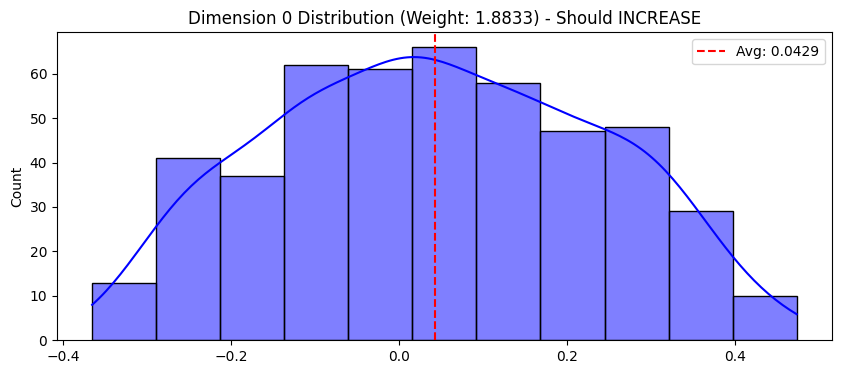

Top titles for Dim 0 (direction: INCREASE):
- Adam Mosseri: Beyond the Algorithm—How Meta Controls Global Attention in the Age of AI (Value: 0.4737)
- Adam Mosseri: How Meta Maintains Global Dominance in the Face of the AI Paradigm Shift (Value: 0.4583)
- Adam Mosseri: How Meta Engineered the Future of Social and Why AI Will Not Replace It (Value: 0.4472)
- Adam Mosseri: How Meta Will Use Their User Base to Dominate the AI Agent Landscape (Value: 0.4425)
- Arthur Mensch: How Mistral AI Will Define the Future of Models (Value: 0.4401)




In [36]:
analyze_individual_dimensions(df, "20VC with Harry Stebbings", eval_dataset, pca, embedding_model)

### Individual Dimension Breakdown for a16z


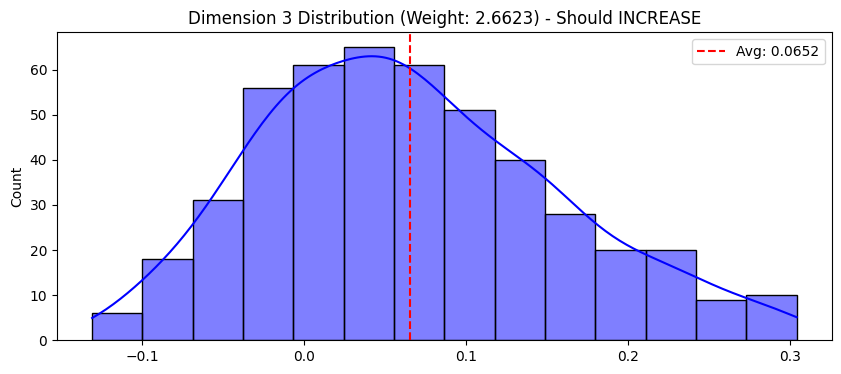

Top titles for Dim 3 (direction: INCREASE):
- The Great Realignment: JD Vance on Tech, Geopolitics, and American Power (Value: 0.3041)
- JD Vance: How America’s Tech Giants Lost Their Influence (Value: 0.3039)
- JD Vance: The Inside Story of the New Silicon Valley-Washington Power Alliance (Value: 0.3008)
- Truth Terminal: Why Human CEOs Are Losing the War for Market Attention (Value: 0.2892)
- JD Vance: Why the Global Tech Order Is Collapsing (And How America Wins the Reset) (Value: 0.2892)




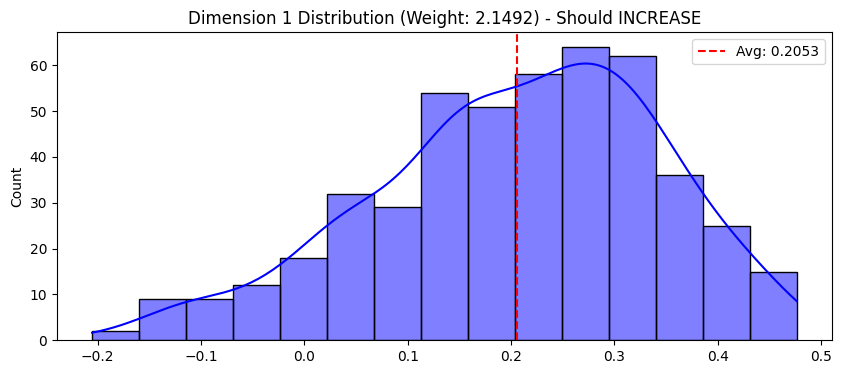

Top titles for Dim 1 (direction: INCREASE):
- The AI Arms Race: Why the New Global Hegemony Will Be Built on Compute (Value: 0.4763)
- The AI Supremacy Battle: Why the Next Global Superpower Will Be Won in Code (Value: 0.4661)
- From Software to Survival: The AI Race That Will Define the Next Century (Value: 0.4617)
- The Epoch Forecast: Why AI Will Become the New Foundation of Global Hegemony (Value: 0.4611)
- The Shift to Superintelligence: Why Nations Will Fight to Own the AI Core (Value: 0.4606)




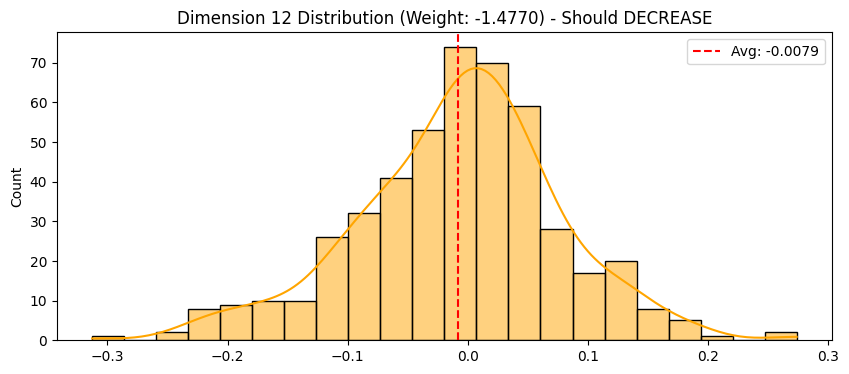

Top titles for Dim 12 (direction: DECREASE):
- From Zero to Viral: Inside the Startup That is Rebuilding the Media Ecosystem (Value: -0.3128)
- The End of Music? How Udio is Upending the Global Entertainment Economy (Value: -0.2495)
- Beyond the Song: Why AI-Generated Audio is the Biggest Shift in Media Since the Internet (Value: -0.2375)
- From Text to Tune: How AI is Disrupting the Global Music Market (Value: -0.2315)
- Inside the AI Startup Changing How We Build Billion-Dollar Media Hits (Value: -0.2231)




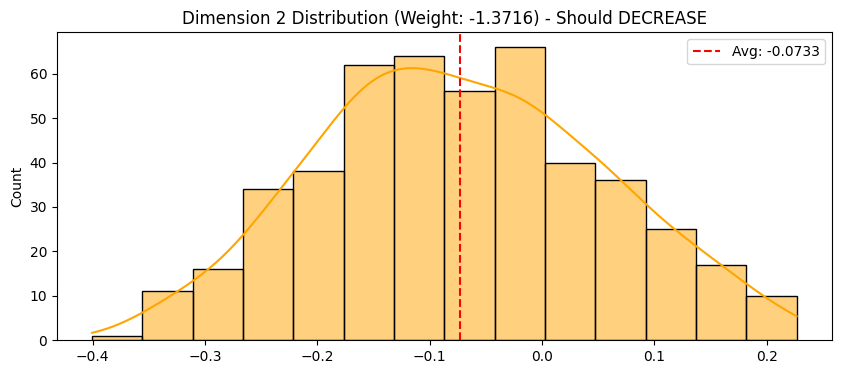

Top titles for Dim 2 (direction: DECREASE):
- Why Your Business Model Will Fail Without AI Agents: The New Reality of Autonomous Scaling (Value: -0.4003)
- Inside the AI Startup Changing How We Build Billion-Dollar Media Hits (Value: -0.3457)
- Truth Terminal: When AI Becomes a Billion-Dollar Venture Capitalist (Value: -0.3451)
- The Future of Sound: Inside the AI Startup Disrupting the $25B Music Industry (Value: -0.3419)
- Truth Terminal: How Autonomous AI Agents Are Redefining Modern Venture Capital (Value: -0.3411)




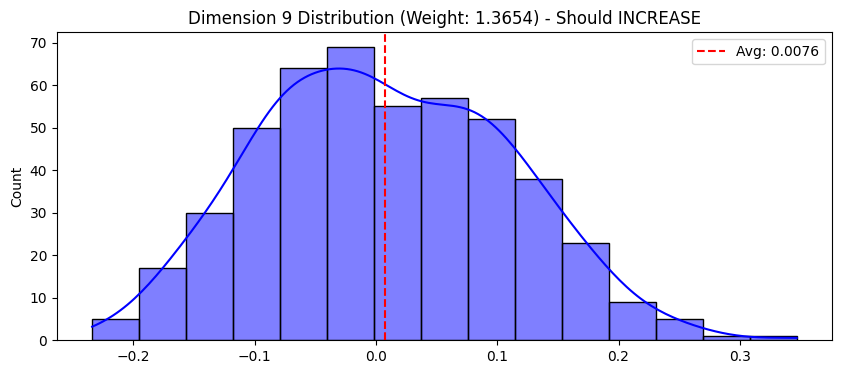

Top titles for Dim 9 (direction: INCREASE):
- Why the Next Superpower Will Be Built in Silicon Valley (Value: 0.3468)
- Truth Terminal: Why the Next Billion-Dollar "Founder" Won’t Be Human (Value: 0.2766)
- Silicon Valley’s New Mission: Building the Technology That Wins the Next War (Value: 0.2592)
- Can America’s Tech Giants Outpace China in the New Digital Battlefield? (Value: 0.2476)
- The New Arms Race: Why Billion-Dollar Founders Are Building Hardware (Value: 0.2415)




In [37]:
analyze_individual_dimensions(df, "a16z", eval_dataset, pca, embedding_model)

## Multivariate Alignment: Correlation and Trade-offs

How do different dimensions interact? We compute the degree of alignment in the top 5 most significant dimensions and visualize their correlations using a confusion matrix of their directions.

In [60]:
def analyze_multivariate_alignment(df, channel_name, eval_dataset, pca, embedding_model):
    channel_df = df[df['channel'] == channel_name]
    channel_eval = next(c for c in eval_dataset if c['channel_name'].lower() == channel_name.lower())
    coeffs = channel_eval['model']['coefficients']
    top_5_indices = np.argsort(np.abs(coeffs))[-5:][::-1]

    # Get dimension descriptions
    print(f"### Dimension Descriptions for {channel_name}")
    cid = channel_eval['channel_id']
    desc = llm_analysis['channel_significant_dimension_analysis'].get(cid, "Descriptions not found")
    print(desc)

    # Extract values for top 5 dimensions for all optimized titles
    all_titles = []
    for _, row in channel_df.iterrows():
        for it in row['history']:
            for t in it['titles']:
                all_titles.append(t['text'])

    all_titles = list(set(all_titles))
    embs = embedding_model.encode(all_titles)
    projs = pca.transform(embs)[:, top_5_indices]

    # Normalize by desired direction (multiply by sign of weight)
    signs = np.sign([coeffs[i] for i in top_5_indices])
    aligned_projs = projs * signs

    # Confusion Matrix (Correlation) of aligned directions
    corr_matrix = pd.DataFrame(aligned_projs, columns=[f'Dim {i}' for i in top_5_indices]).corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Directional Correlation Matrix for Top 5 Dimensions ({channel_name})")
    plt.show()

    # Compare to Human titles
    human_titles = channel_df['original_title'].tolist()
    h_embs = embedding_model.encode(human_titles)
    h_projs = pca.transform(h_embs)[:, top_5_indices] * signs

    print("\nAverage Alignment (Normalized Score):")
    print(f"AI Optimized Average: {aligned_projs.mean(axis=0)}")
    print(f"Human Average:        {h_projs.mean(axis=0)}")



### Dimension Descriptions for 20VC with Harry Stebbings
### Performance Drivers for '20VC with Harry Stebbings'

To predict the view counts of new video titles on the **20VC with Harry Stebbings** YouTube channel, we analyze the five most statistically significant Principal Component Analysis (PCA) dimensions. 

The channel’s audience is highly targeted: it is composed of tech founders, venture capitalists, builders, and tech-sector enthusiasts. Consequently, the performance of a video is driven by a strong preference for **high-stakes institutional tech dynamics, concrete product/company execution, and monetization strategies** over general lifestyle advice, geopolitical state-craft, or personal vulnerability narratives.

Below is the structured breakdown of these drivers, ordered from most statistically significant to least.

---

### 1. Dimension 3: Institutional Analysis & Macro-Power Dynamics vs. Algorithmic Optimization & Individual Utility
* **P-value:** 3.5227e-17 | **Effect:*

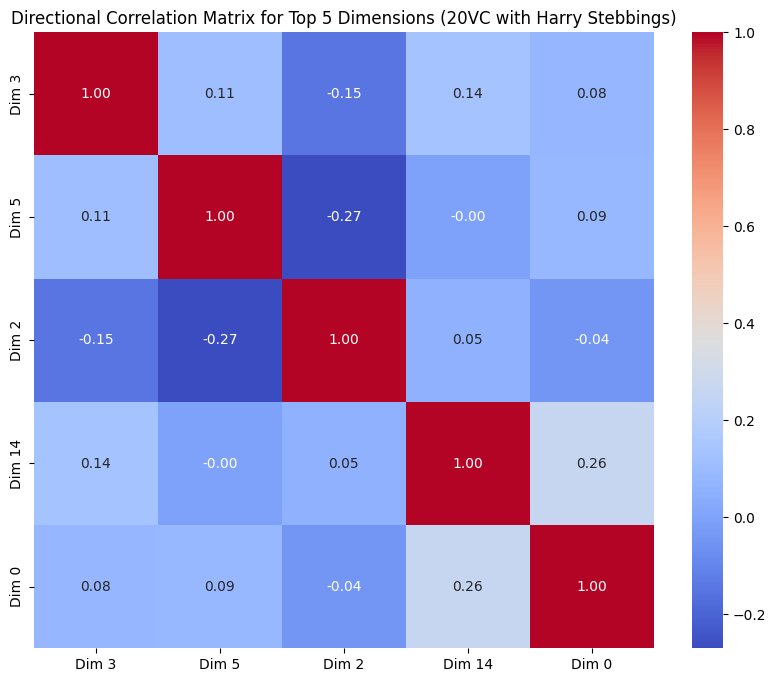


Average Alignment (Normalized Score):
AI Optimized Average: [ 0.09936219 -0.02597539  0.15365361 -0.03291005  0.04285631]
Human Average:        [0.10621339 0.03225425 0.0706684  0.00817651 0.03900507]


In [61]:
analyze_multivariate_alignment(df, "20VC with Harry Stebbings", eval_dataset, pca, embedding_model)


### Dimension Descriptions for a16z
To predict the performance (views) of video titles on the **a16z** YouTube channel, we analyze the five most statistically significant dimensions derived from Principal Component Analysis (PCA). 

For a16z, high-performing content typically transcends dry, day-to-day operational advice or niche engineering. Instead, the channel's audience responds best to **macro-scale power dynamics, institutional governance, high-stakes geopolitical narratives, and digital-economy attention dynamics**.

Below is the structured breakdown of the 5 dimensions, ordered from most to least statistically significant, followed by a cohesive predictive description.

---

### 1. Dimension 3: Institutional Analysis & Macro-Power Dynamics vs. Algorithmic Optimization & Individual Utility
* **P-value:** 1.4764e-04 (Most Significant)
* **Effect:** **POSITIVE** (Leaning toward the Positive pole drives *higher* views)
* **Magnitude:** 2.6623

#### Performance Driver:
Content that 

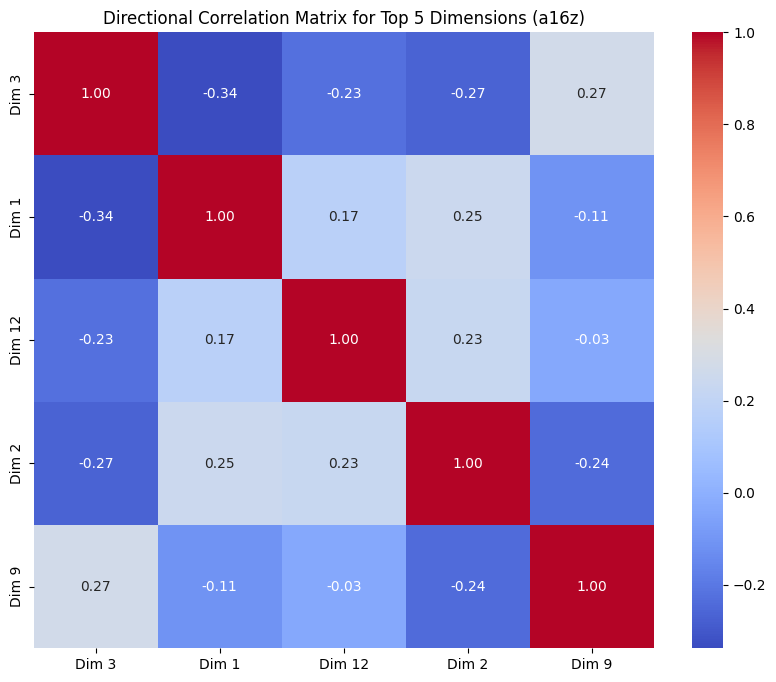


Average Alignment (Normalized Score):
AI Optimized Average: [0.06521011 0.20528289 0.00786524 0.07332663 0.00763836]
Human Average:        [ 0.00320184  0.06404749 -0.02861652 -0.00263859 -0.067438  ]


In [62]:
analyze_multivariate_alignment(df, "a16z", eval_dataset, pca, embedding_model)

## The Optimization Landscape: Visualizing Trajectories to Success

Where do the best titles live? We project the high-performance suggestions and original human titles into a 2D space to visualize the semantic clusters associated with success.

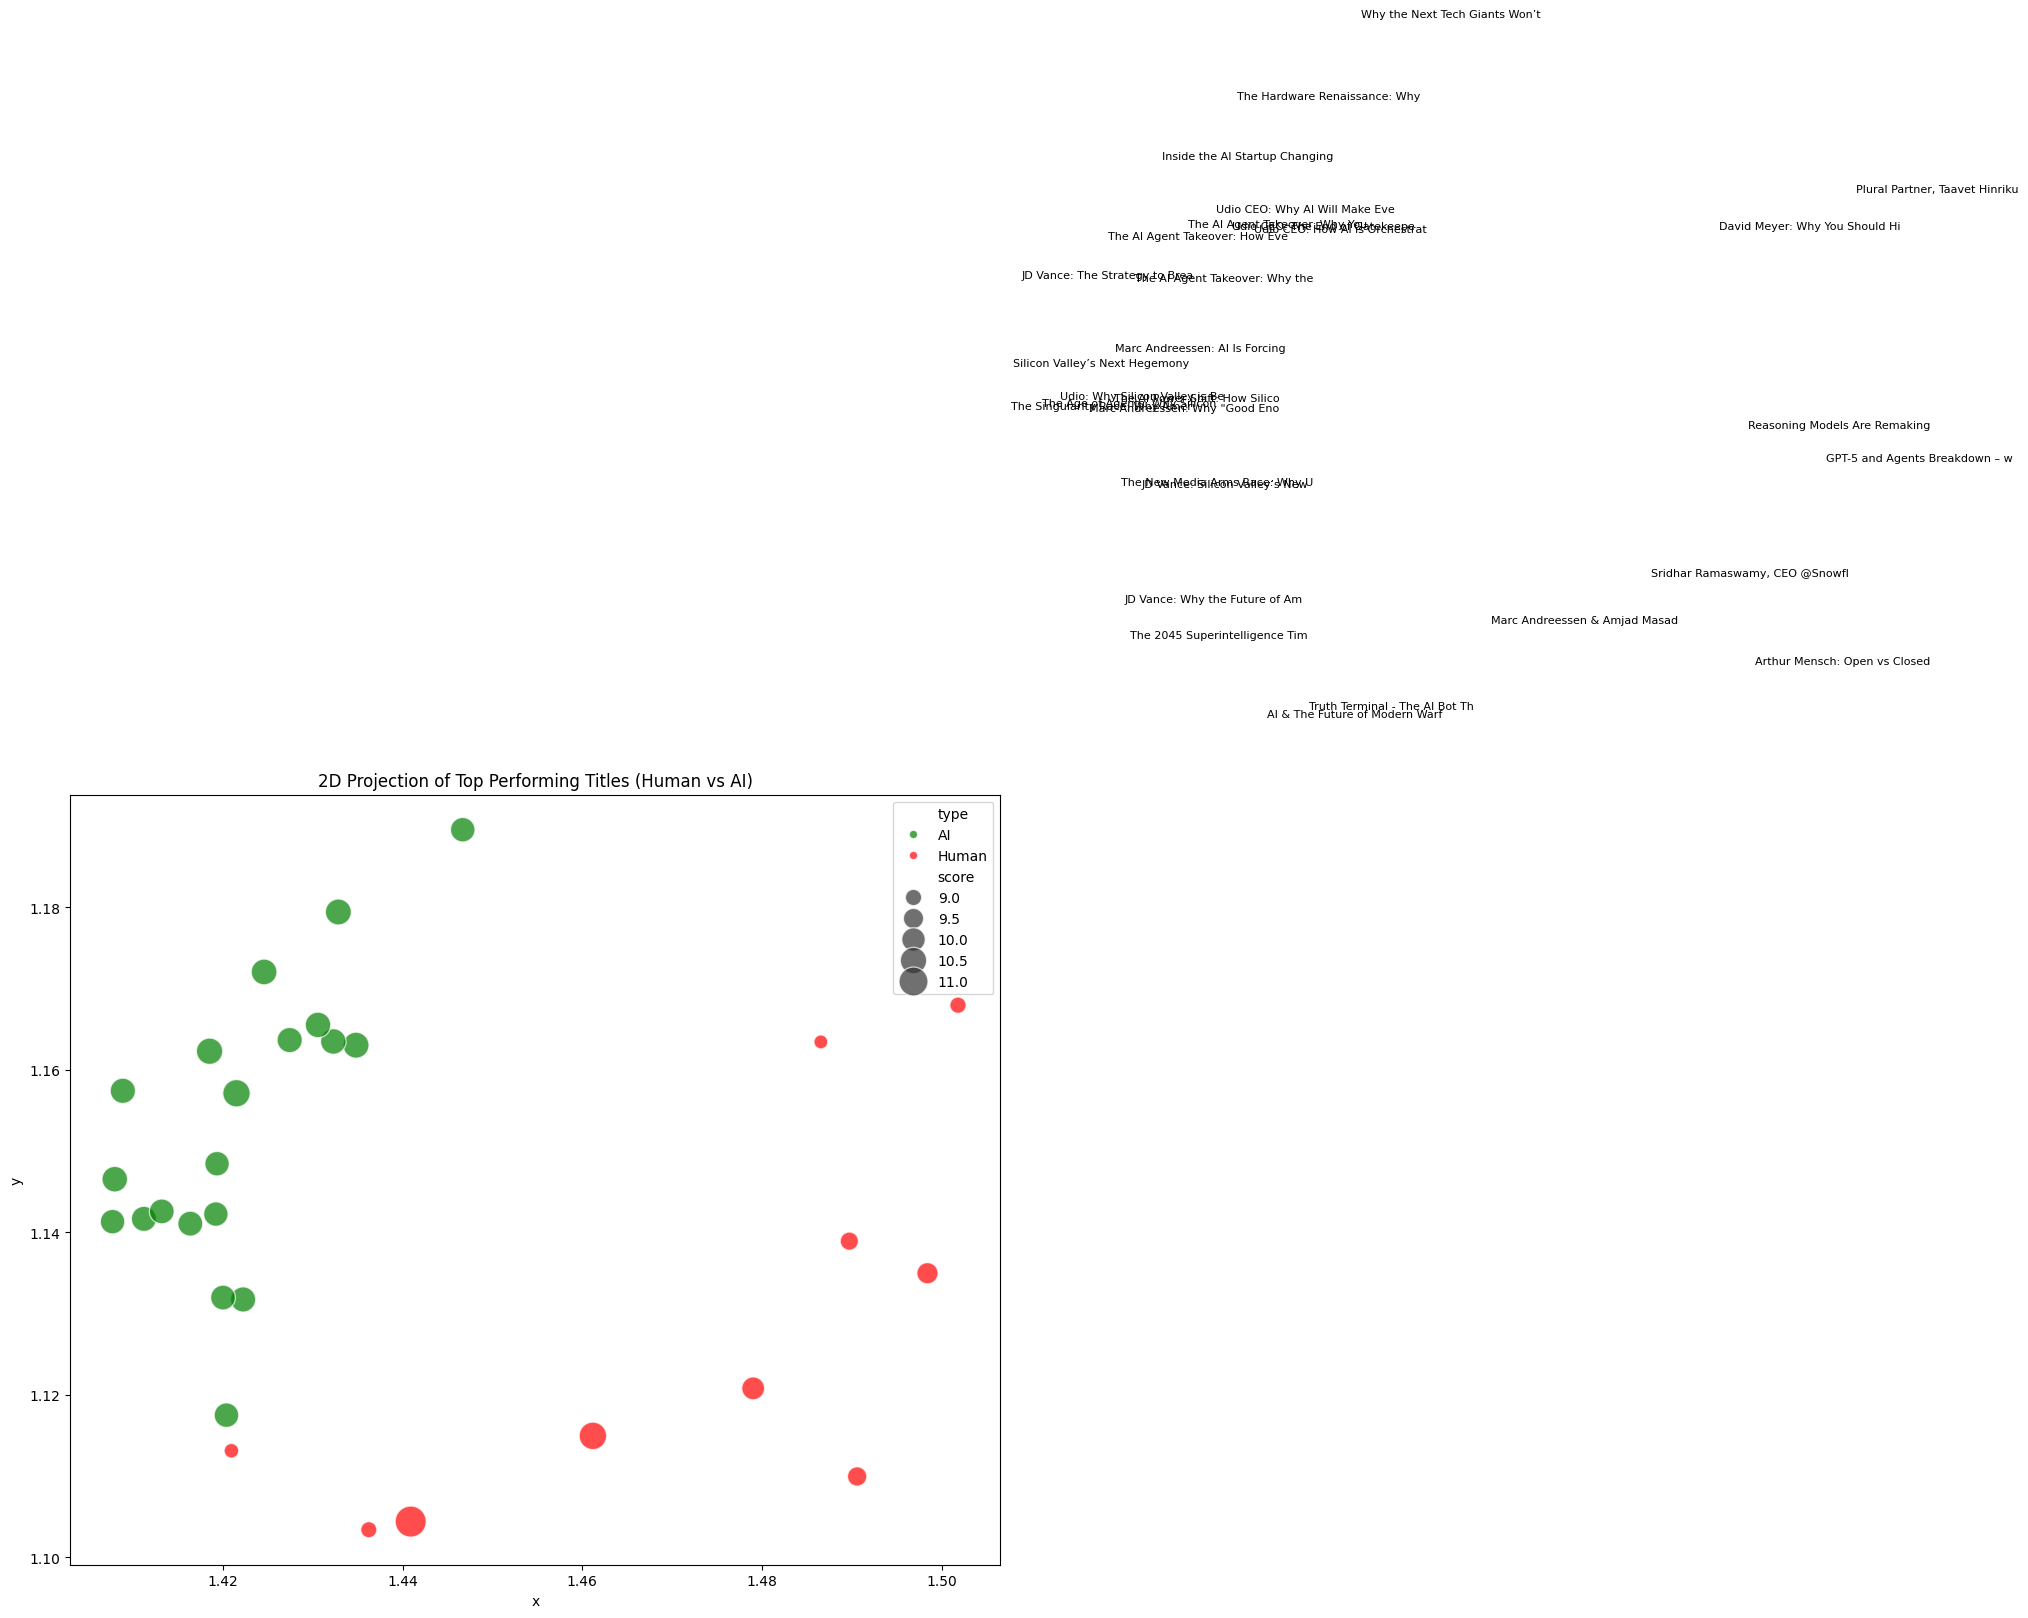

### Distance and Iteration Analysis
Average distance between top AI and top Human titles (15D): 0.6517

#### Top 10 Overall Suggestions


,title,score,iteration,original_video
349,The AI Agent Takeover: Why the Next 24 Months ...,10.694427,5,GPT-5 and Agents Breakdown – w/ OpenAI Researc...
321,The AI Agent Takeover: How Every Major Industr...,10.499344,3,GPT-5 and Agents Breakdown – w/ OpenAI Researc...
41,Udio CEO: How AI is Orchestrating the Next $10...,10.433404,5,Udio: From Text to Tune
387,The Hardware Renaissance: Why Top Founders are...,10.428679,4,How to Enable a Manufacturing Renaissance
23,Inside the AI Startup Changing How We Build Bi...,10.385870,3,Udio: From Text to Tune
336,Silicon Valley’s Next Hegemony: Why AI Agents ...,10.360752,4,GPT-5 and Agents Breakdown – w/ OpenAI Researc...
45,Udio CEO: The End of Gatekeepers and the Rise ...,10.356751,5,Udio: From Text to Tune
32,Udio CEO: Why AI Will Make Every Creator a One...,10.352517,4,Udio: From Text to Tune
491,JD Vance: The Strategy to Break China’s AI Dom...,10.303806,5,JD Vance on the Future of America
337,The AI Agent Takeover: Why Your Business Model...,10.298213,4,GPT-5 and Agents Breakdown – w/ OpenAI Researc...


/tmp/ipykernel_25877/2111791066.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=top_ai, x='iteration', palette='viridis')


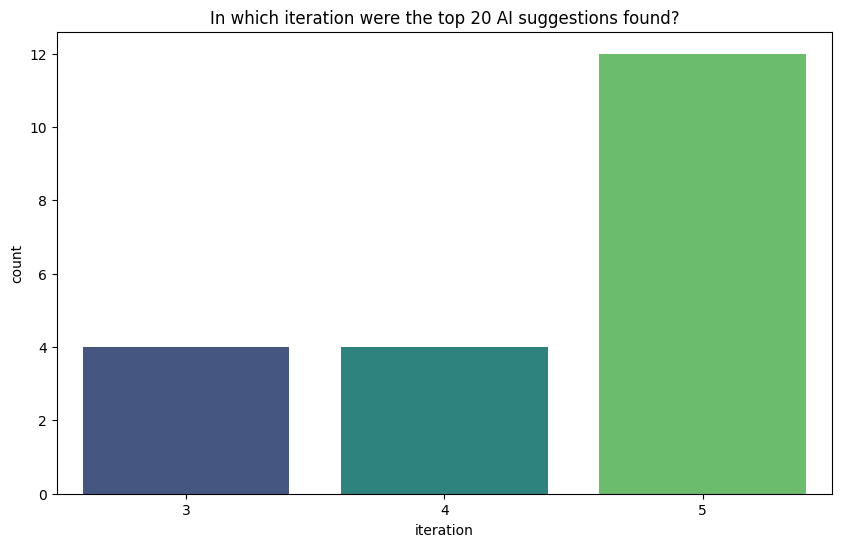

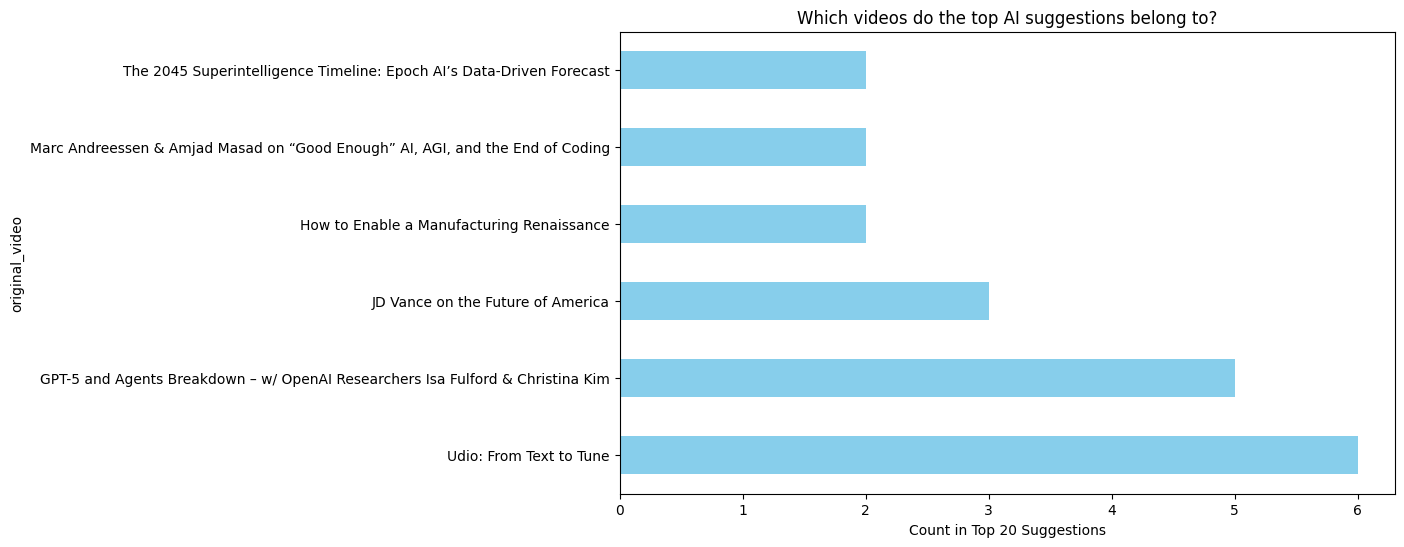

In [39]:
def analyze_optimization_landscape(df, pca, embedding_model):
    all_titles_data = []

    # 1. Collect best AI suggestions (overall, top 20 across all videos)
    all_ai_suggestions = []
    for _, row in df.iterrows():
        for it in row['history']:
            for t in it['titles']:
                all_ai_suggestions.append({
                    'title': t['text'],
                    'score': t['score'],
                    'iteration': it['iteration'],
                    'original_video': row['original_title'],
                    'type': 'AI'
                })

    top_ai = pd.DataFrame(all_ai_suggestions).sort_values('score', ascending=False).head(20)

    # 2. Collect best Human titles (top 10)
    top_human = df.sort_values('original_score', ascending=False).head(10).copy()
    top_human['type'] = 'Human'
    top_human = top_human.rename(columns={'original_title': 'title', 'original_score': 'score'})
    top_human['iteration'] = 0
    top_human['original_video'] = top_human['title']

    combined_best = pd.concat([top_ai[['title', 'score', 'type', 'iteration', 'original_video']],
                               top_human[['title', 'score', 'type', 'iteration', 'original_video']]])

    embs = embedding_model.encode(combined_best['title'].tolist())
    # Use t-SNE for 2D projection of the 15D PCA space
    projs_15d = pca.transform(embs)
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(combined_best)-1))
    projs_2d = tsne.fit_transform(projs_15d)

    combined_best['x'] = projs_2d[:, 0]
    combined_best['y'] = projs_2d[:, 1]

    plt.figure(figsize=(12, 10))
    sns.scatterplot(data=combined_best, x='x', y='y', hue='type', size='score',
                    sizes=(100, 500), palette={'AI': 'green', 'Human': 'red'}, alpha=0.7)

    for i, row in combined_best.reset_index().iterrows():
        plt.text(row['x']+0.1, row['y']+0.1, row['title'][:30], fontsize=8)

    plt.title("2D Projection of Top Performing Titles (Human vs AI)")
    plt.show()

    # Distances analysis
    # Distance from best AI to closest best Human in 15D space
    from sklearn.metrics import euclidean_distances
    ai_idx = combined_best['type'] == 'AI'
    human_idx = combined_best['type'] == 'Human'
    dist_matrix = euclidean_distances(projs_15d[ai_idx], projs_15d[human_idx])

    print("### Distance and Iteration Analysis")
    print(f"Average distance between top AI and top Human titles (15D): {dist_matrix.mean():.4f}")

    # Table of top performing suggestions
    print("\n#### Top 10 Overall Suggestions")
    display(top_ai.head(10)[['title', 'score', 'iteration', 'original_video']])

    # Iteration analysis
    plt.figure(figsize=(10, 6))
    sns.countplot(data=top_ai, x='iteration', palette='viridis')
    plt.title("In which iteration were the top 20 AI suggestions found?")
    plt.show()

    # Video membership
    plt.figure(figsize=(10, 6))
    top_ai['original_video'].value_counts().plot(kind='barh', color='skyblue')
    plt.title("Which videos do the top AI suggestions belong to?")
    plt.xlabel("Count in Top 20 Suggestions")
    plt.show()

analyze_optimization_landscape(df, pca, embedding_model)

## Contrastive Linguistic Analysis: Style and Semantics

What makes a title fail or succeed? We contrast the linguistic styles of the top-performing and bottom-performing suggestions discovered during the optimization process.

In [40]:
def analyze_linguistic_differences(df):
    all_ai = []
    for _, row in df.iterrows():
        for it in row['history']:
            for t in it['titles']:
                all_ai.append({'text': t['text'], 'score': t['score']})

    ai_df = pd.DataFrame(all_ai).sort_values('score', ascending=False)
    top_titles = ai_df.head(20)['text'].tolist()
    bottom_titles = ai_df.tail(20)['text'].tolist()

    print("### Top Performing Stylistic Patterns")
    for t in top_titles[:5]: print(f"[SUCCESS] {t}")

    print("\n### Bottom Performing Stylistic Patterns")
    for t in bottom_titles[:5]: print(f"[FAILURE] {t}")

    # simple feature extraction: length, number of punctuation, capital letters
    def get_features(t):
        return {
            'len': len(t),
            'caps': sum(1 for c in t if c.isupper()),
            'punc': sum(1 for c in t if c in '!:?.,')
        }

    top_feats = pd.DataFrame([get_features(t) for t in top_titles])
    bottom_feats = pd.DataFrame([get_features(t) for t in bottom_titles])

    print("\n### Average Structural Differences")
    stats_df = pd.DataFrame({
        'Metric': ['Length', 'Capitals', 'Punctuation'],
        'Top Performers': [top_feats['len'].mean(), top_feats['caps'].mean(), top_feats['punc'].mean()],
        'Bottom Performers': [bottom_feats['len'].mean(), bottom_feats['caps'].mean(), bottom_feats['punc'].mean()]
    })
    display(stats_df)

analyze_linguistic_differences(df)

### Top Performing Stylistic Patterns
[SUCCESS] The AI Agent Takeover: Why the Next 24 Months Will Determine the Future of the Tech Hegemony
[SUCCESS] The AI Agent Takeover: How Every Major Industry Will Be Disrupted by 2026
[SUCCESS] Udio CEO: How AI is Orchestrating the Next $100B Media Empire
[SUCCESS] The Hardware Renaissance: Why Top Founders are Shifting from AI to Industrial Might
[SUCCESS] Inside the AI Startup Changing How We Build Billion-Dollar Media Hits

### Bottom Performing Stylistic Patterns
[FAILURE] From Zero to $100M: The Specific Hiring Logic Behind 1Password’s Sales Dominance
[FAILURE] The Hiring Arbitrage: Why You Should Never Hire From Your Competitors
[FAILURE] Sales Execution Failure: Why Your First 5 Hires Are Killing Your Revenue Growth
[FAILURE] How to Build A World-Class Product Team: The Hidden Hiring Bias You’re Missing
[FAILURE] Stop Hiring Product Managers: The Counter-Intuitive Strategy for Hyper-Growth

### Average Structural Differences


,Metric,Top Performers,Bottom Performers
0,Length,73.0,80.55
1,Capitals,11.9,11.25
2,Punctuation,0.9,1.15
